# Adsorbent bed service life - data walkthrough

This notebook reproduces the analysis in the repository from the published data only.
**Aspen is not required.** Everything below runs on the two CSV files in `data/`.

See [README.md](README.md) for the method and the full discussion.


In [1]:
import os, sys, subprocess
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.insert(0, "src")
import make_figures as mf

print("python:", sys.version.split()[0])


python: 3.14.2


## 1. The data

Two samples of rigorous Aspen Adsorption runs, generated automatically over a parameter grid.

- `runs.csv` - three parameters: bed temperature, residual adsorbent capacity, feed concentration
- `runs4.csv` - adds the residual loading left in the bed after regeneration


In [2]:
d = mf.load("runs.csv")
d4 = mf.load("runs4.csv")

# rows where the bed is off-spec from the first step are an artefact, not a breakthrough time
keep = d4["t_breakthrough_h"] > 0.5
d4 = {k: v[keep] for k, v in d4.items()}

print("runs.csv :", len(d["t_breakthrough_h"]), "runs")
print("runs4.csv:", len(d4["t_breakthrough_h"]), "runs after filtering")
print()
for name, arr in [("bed temperature, C", d["T_C"]),
                  ("residual capacity", d["capacity_frac"]),
                  ("feed methanol, ppm", d["y_methanol_ppm"]),
                  ("breakthrough time, h", d["t_breakthrough_h"])]:
    print("{:24s} {:8.2f} .. {:8.2f}".format(name, np.nanmin(arr), np.nanmax(arr)))


runs.csv : 166 runs
runs4.csv: 42 runs after filtering

bed temperature, C          25.00 ..    65.00
residual capacity            0.42 ..     1.00
feed methanol, ppm          88.00 ..   226.00
breakthrough time, h         1.42 ..    34.17


## 2. Operating map

Methanol at the outlet at the start of the cycle, in ppm. The specification limit is 10 ppm.

Rows are the residual loading left after regeneration, columns are the bed temperature.
Neither factor alone pushes the unit off-spec; their combination does.


In [3]:
ws = np.unique(np.round(d4["w_residual"], 4))
ts = np.unique(np.round(d4["T_C"], 1))

print("residual", "".join("{:>9.0f} C".format(t) for t in ts))
for w in ws:
    row = "{:6.0f} %  ".format(w * 100)
    for t in ts:
        sel = (np.isclose(np.round(d4["w_residual"], 4), w)
               & np.isclose(np.round(d4["T_C"], 1), t))
        if sel.any():
            row += "{:>11.1f}".format(np.nanmean(d4["y_start_ppm"][sel]))
        else:
            row += "{:>11s}".format("-")
    print(row)


residual        25 C       40 C       45 C       55 C       65 C
     0 %          0.0        0.0        0.0        0.0        0.0
     0 %          3.4        7.3        8.1          -          -
     0 %          7.7          -          -          -          -


## 3. Figures

Built by `src/make_figures.py` from the same data.


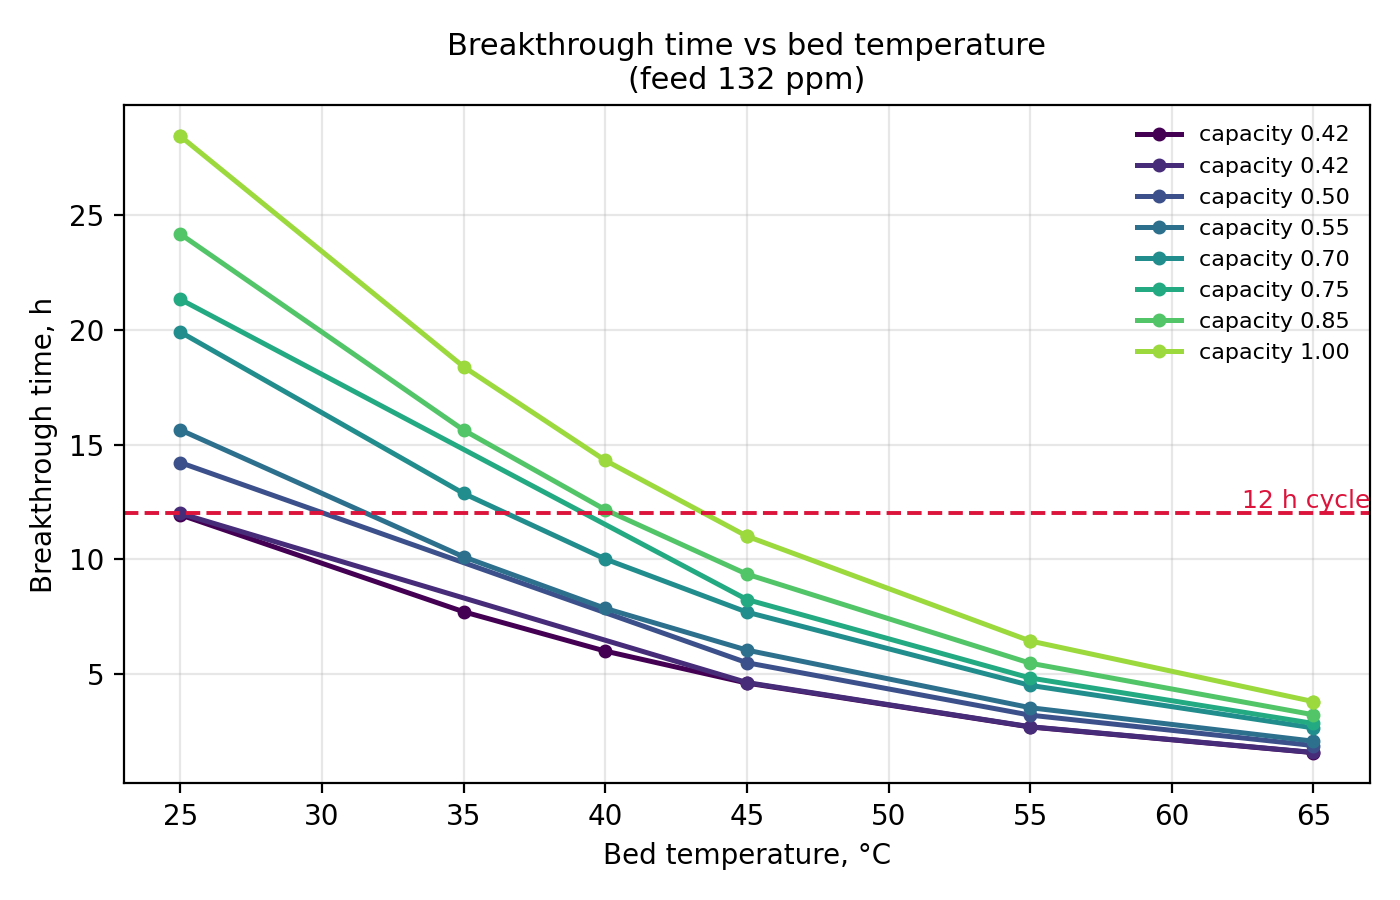

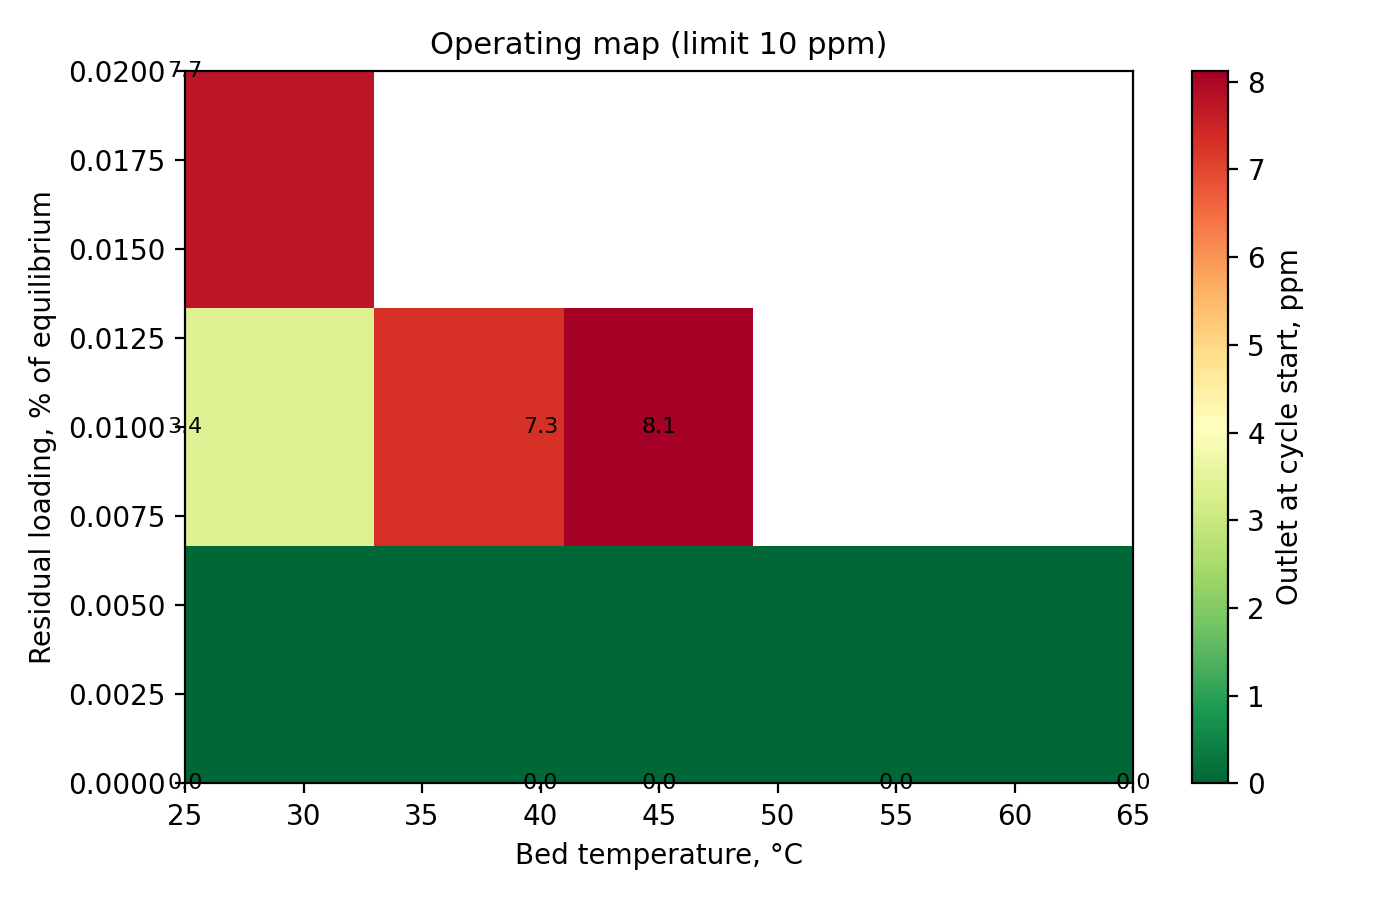

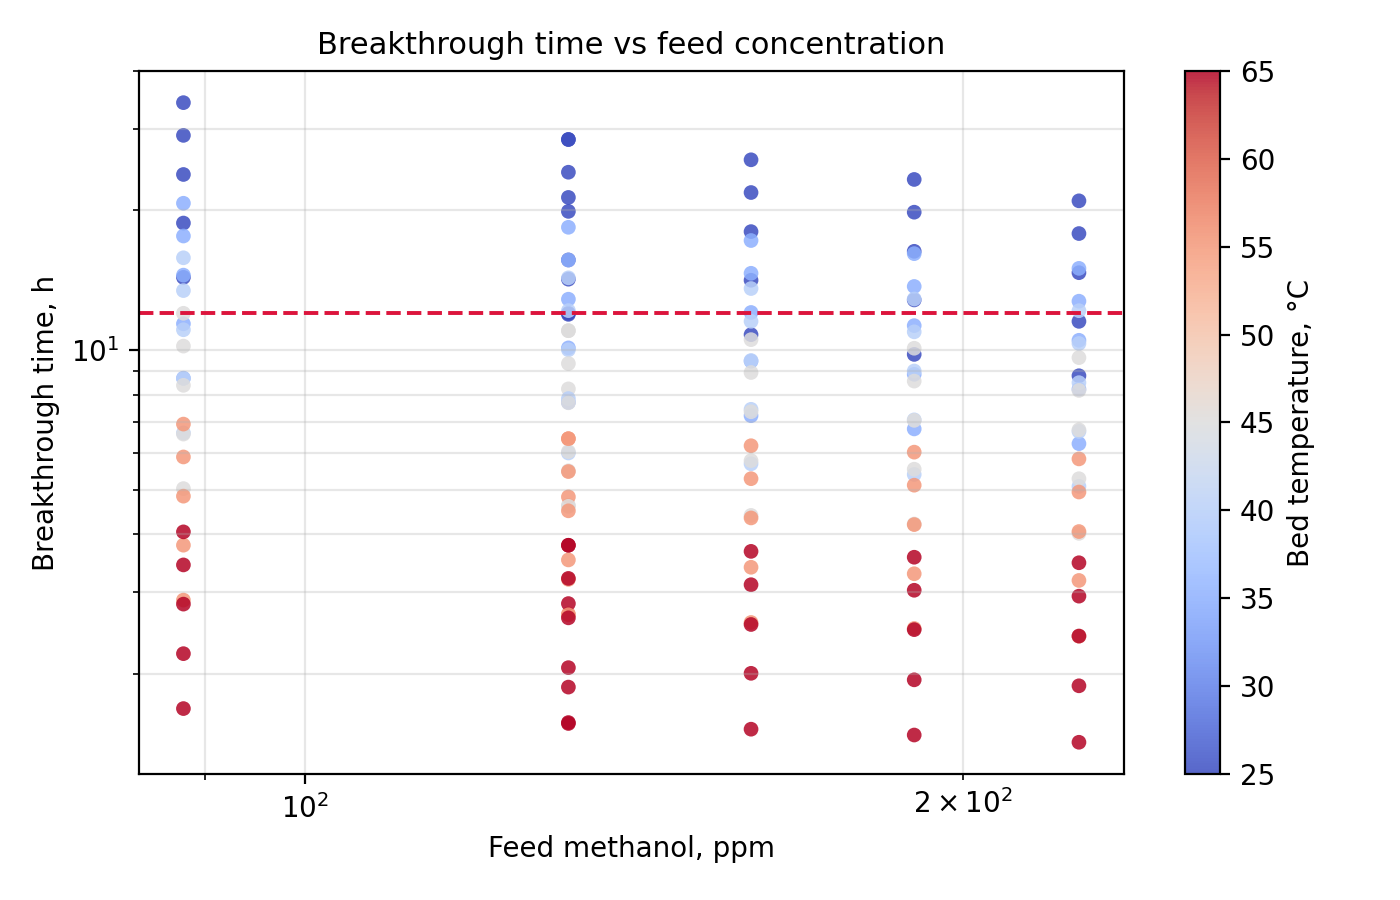

In [4]:
for path in (mf.fig_time_vs_temperature(d),
             mf.fig_operating_map(d4),
             mf.fig_concentration(d)):
    display(Image(filename=path))


## 4. Surrogate model: physics against gradient boosting

`src/surrogate.py` fits three forms on the same hold-out split and prints the metrics.
Random seeds are fixed, so these numbers match the table in the README.


In [5]:
res = subprocess.run([sys.executable, "surrogate.py"], cwd="src",
                     capture_output=True, text=True)
print(res.stdout)
if res.returncode:
    print(res.stderr)



МОДЕЛЬ ВРЕМЕНИ ПРОСКОКА   точек: 166
  физическая (3 коэфф.)              MAPE= 1.056 %   max=  6.24 %   R2=0.999858
    Q = 55363 Дж/моль   k = 2.2329   показатель при ёмкости = 1.0050
  лог-линейная (4 коэфф.)            MAPE= 6.213 %   max= 22.20 %   R2=0.977256
  градиентный бустинг                MAPE= 2.102 %   max=  6.32 %   R2=0.996789

МОДЕЛЬ ВЫХОДА В НАЧАЛЕ ЦИКЛА   точек: 50
  физическая (2 коэфф.)              MAPE= 0.131 %   max=  0.34 %   R2=0.999998
    Q = 51073 Дж/моль   k = 0.8844
  лог-линейная (4 коэфф.)            MAPE= 0.392 %   max=  1.11 %   R2=0.999953
  градиентный бустинг                MAPE= 3.320 %   max= 15.52 %   R2=0.992251

КАРТА РЕЖИМОВ — выход в начале цикла, ppm (норма 10 ppm)
  остаток       25 °C      40 °C      45 °C      55 °C      65 °C
      3 %         1.8        4.9        6.7       12.0       20.9
      6 %         3.7        9.9       13.5       24.4       42.4
     10 %         6.3       16.9       23.0       41.4       72.1
     15 %     

## 5. What comes out of it

- Bed temperature dominates. At 45 C, the lower bound of the design cooling range,
  even a sound and fully regenerated bed does not sustain the 12-hour cycle.
- Residual loading and temperature are individually within tolerance but jointly off-spec.
- The physics-based form, with two or three coefficients, matches or beats gradient
  boosting with hundreds of trees. The response is a smooth inverted Langmuir isotherm;
  there is nothing here for a tree ensemble to discover that the physics does not
  already provide.
